In [2]:
# import required libraries
import os
import glob
import zipfile
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split

In [3]:
# Import and unsip and extract the file
import zipfile

z = zipfile.ZipFile('/archive.zip')

z.extractall()


In [4]:
# Correct base path where dataset is extracted
base_dir = '/content/seg_train/seg_train'


In [5]:
classes = {
    "buildings": 0,
    "forest": 1,
    "glacier": 2,
    "mountain": 3,
    "sea": 4,
    "street": 5
}
images = []
labels = []


In [6]:
 #Get image file paths

buildings_paths = glob.glob(os.path.join(base_dir, 'buildings', '*'))   # All building path
forest_paths = glob.glob(os.path.join(base_dir, 'forest', '*'))   # All forest path
glacier_paths = glob.glob(os.path.join(base_dir, 'glacier', '*'))   # All building path
mountain_paths = glob.glob(os.path.join(base_dir, 'mountain', '*'))   # All forest path
sea_paths = glob.glob(os.path.join(base_dir, 'sea', '*'))   # All forest path
street_paths = glob.glob(os.path.join(base_dir, 'street', '*'))   # All forest path

# Print number of images found
print('Found', len(buildings_paths), 'Building images')
print('Found', len(forest_paths), 'forest images')
print('Found', len(glacier_paths), 'glacier images')
print('Found', len(mountain_paths), 'mountain images')
print('Found', len(sea_paths), 'sea images')
print('Found', len(street_paths), 'street images')

Found 2191 Building images
Found 2271 forest images
Found 2404 glacier images
Found 2512 mountain images
Found 2274 sea images
Found 2382 street images


In [7]:
#path of each class
buildings = os.listdir("/content/seg_train/seg_train/buildings")
Count_of_buildings = len(buildings)
print(Count_of_buildings)

forest = os.listdir("/content/seg_train/seg_train/forest")
Count_of_forest = len(forest)
print(Count_of_forest)

glacier = os.listdir("/content/seg_train/seg_train/glacier")
Count_of_glacier = len(glacier)
print(Count_of_glacier)

mountain = os.listdir("/content/seg_train/seg_train/mountain")
Count_of_mountain = len(mountain)
print(Count_of_mountain)

sea = os.listdir("/content/seg_train/seg_train/sea")
Count_of_sea = len(sea)
print(Count_of_sea)

street = os.listdir("/content/seg_train/seg_train/street")
Count_of_street = len(street)
print(Count_of_street)

2191
2271
2404
2512
2274
2382


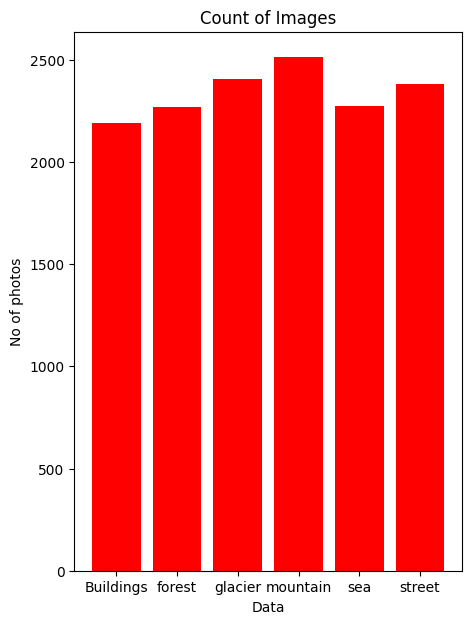

In [8]:
import matplotlib.pyplot as plt
data = {'Buildings': Count_of_buildings, 'forest': Count_of_forest,'glacier': Count_of_glacier,'mountain': Count_of_mountain,'sea': Count_of_sea,'street': Count_of_street}

typex = data.keys()
values = data.values()

fig = plt.figure(figsize=(5,7))

plt.bar(typex, values, color="red")

plt.xlabel("Data")
plt.ylabel("No of photos")
plt.title("Count of Images")
plt.show()

Analytical Question 1 (Markdown): What challenges do variations in lighting, viewpoint, and class imbalance introduce in satellite scene classification?

Ans:-It can affect incorrect extraction of feature and It can also cause bias to a perticular class

In [9]:
# Read images from folders
for folder in classes:

    folder_path = os.path.join(base_dir, folder)
    files = glob.glob(os.path.join(folder_path, "*"))

    print(f"{folder} -> {len(files)} images")

    for file in files:
        try:
            img = image.load_img(file, target_size=(64, 64))
            img = image.img_to_array(img)
            img = img / 255.0

            images.append(img)
            labels.append(classes[folder])

        except Exception as e:
            print("Skipped:", file)

buildings -> 2191 images
forest -> 2271 images
glacier -> 2404 images
mountain -> 2512 images
sea -> 2274 images
street -> 2382 images


In [10]:

# Convert lists to numpy arrays
x = np.array(images)
y = np.array(labels)

print("Image data shape:", x.shape)
print("Label shape:", y.shape)


Image data shape: (14034, 64, 64, 3)
Label shape: (14034,)


In [11]:
# Convert lists to numpy arrays
x = np.array(images)
y = np.array(labels)

print("Image data shape:", x.shape)
print("Label shape:", y.shape)

Image data shape: (14034, 64, 64, 3)
Label shape: (14034,)


In [12]:
# Convert labels to categorical format
y = to_categorical(y, num_classes=6)

Analytical Question 2 (Markdown): How does data augmentation help reduce overfitting in image-based deep learning models?

ans:- Augmentation will help to stabilize the data,which will help to reduce the biase and overfitting

In [13]:
# Split data
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
# CNN Model
model = Sequential()

model.add(Conv2D(32, (3, 3), activation="relu",
                 input_shape=(64, 64, 3)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(6, activation="softmax"))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Analytical Question 3 (Markdown): Explain how convolution and pooling operations contribute to feature extraction in CNNs.

Ans:-While pooling operations function as a compressor to stabilize, reduce, and aggregate those patterns, convolution operations serve as the main detector that finds localized patterns.

In [15]:
# compile  the model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [16]:
# Train
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_test, y_test)
)


Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.5400 - loss: 1.1630 - val_accuracy: 0.6587 - val_loss: 0.9196
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6850 - loss: 0.8639 - val_accuracy: 0.7253 - val_loss: 0.7570
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7320 - loss: 0.7481 - val_accuracy: 0.7763 - val_loss: 0.6278
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7708 - loss: 0.6448 - val_accuracy: 0.7830 - val_loss: 0.6195
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7946 - loss: 0.5931 - val_accuracy: 0.7994 - val_loss: 0.5621


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Prediction: street
C: 0.548735


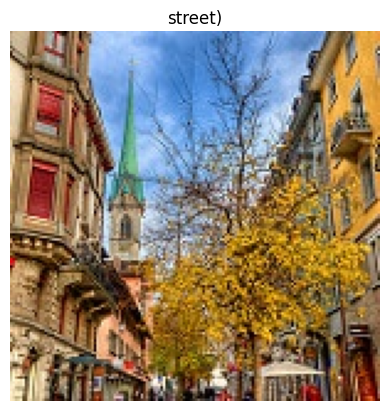

In [20]:
img_path = "/content/seg_pred/seg_pred/10004.jpg"

img = image.load_img(img_path, target_size=(64, 64))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

pred_class = np.argmax(prediction)

print("Prediction:", class_names[pred_class])
print("C:", np.max(prediction))

# load original image for display (without resizing)
img_display = image.load_img('/content/seg_pred/seg_pred/10004.jpg')

plt.imshow(img_display)
plt.axis("off")
plt.title(f"{class_names[pred_class]})")
plt.show()

In [21]:
# Check performance
loss, acc = model.evaluate(x_test, y_test)

print("Accuracy:", round(acc * 100, 2), "%")

88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7994 - loss: 0.5621
Accuracy: 79.94 %


In [22]:
# Save model
model.save("scene_classification_model.h5")

print("Model saved")

Model saved
